# Gap fillers: erfcx, dawsn, Lambert W, and betainc gradients

Smaller functions with long-standing requests behind them: Lambert W is
jax#13680, betainc gradients in the shape parameters are jax#38610, and
erfcx/dawsn round out the erf family (erf, erfc, erfinv are XLA-native,
these two are not in jax).

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as sps

jax.config.update("jax_enable_x64", True)

import chebax

## erfcx and the far Gaussian tail

erfcx(x) = e^{x^2} erfc(x) is how you work with Gaussian tails without
overflow or 0/0. Example: the mean of a normal truncated to [a, inf) is

$$E[X \mid X > a] = \frac{\phi(a)}{1 - \Phi(a)}
  = \sqrt{2/\pi} \; / \; \mathrm{erfcx}(a/\sqrt{2})$$

The naive ratio dies around a = 9 where 1 - Phi(a) underflows in the
straightforward computation; the erfcx form is stable arbitrarily far
out.

In [2]:
def tail_mean_naive(a):
    phi = jnp.exp(-a * a / 2) / jnp.sqrt(2 * jnp.pi)
    Phi = 0.5 * (1 + jax.scipy.special.erf(a / jnp.sqrt(2.0)))
    return phi / (1 - Phi)

def tail_mean_stable(a):
    return jnp.sqrt(2 / jnp.pi) / chebax.erfcx(a / jnp.sqrt(2.0))

print(f"{'a':>5s} {'naive':>22s} {'erfcx form':>22s}")
for a in [1.0, 5.0, 9.0, 30.0, 100.0]:
    print(f"{a:5.0f} {float(tail_mean_naive(a)):22.15g} "
          f"{float(tail_mean_stable(a)):22.15g}")

    a                  naive             erfcx form


    1       1.52513527616098       1.52513527616098
    5       5.18650396833233       5.18650396712584
    9                    inf       9.10852310500287
   30                    inf       30.0332596674337
  100                    nan       100.009998000999


Both erfcx and dawsn satisfy simple ODEs, which make good gradient
checks with no reference implementation at all: D' = 1 - 2xD and
erfcx' = 2x erfcx - 2/sqrt(pi).

dawsn ODE residual  max |D' - (1 - 2xD)|: 3.4035274598664955e-15


erfcx ODE residual  max |E' - (2xE - 2/sqrt(pi))| / (1 + |rhs|): 4.085198880638936e-16


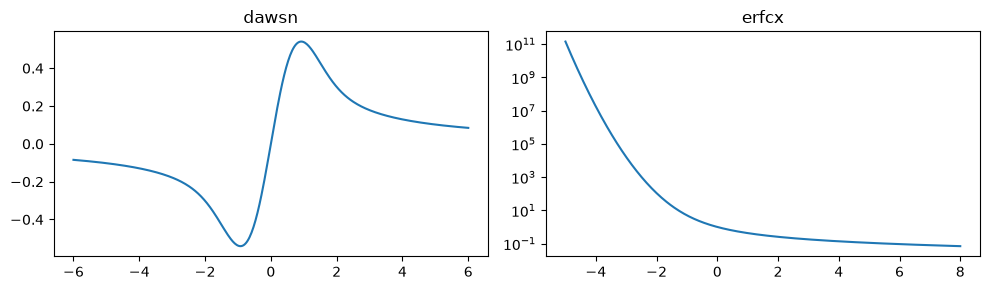

In [3]:
xg = jnp.linspace(-6.0, 6.0, 400)
D = chebax.dawsn(xg)
Dp = jax.vmap(jax.grad(chebax.dawsn))(xg)
print("dawsn ODE residual  max |D' - (1 - 2xD)|:",
      float(jnp.max(jnp.abs(Dp - (1 - 2 * xg * D)))))

# relative residual: for x < 0 both sides grow like e^{x^2}
xe = jnp.linspace(-5.0, 8.0, 400)
E = chebax.erfcx(xe)
Ep = jax.vmap(jax.grad(chebax.erfcx))(xe)
rhs = 2 * xe * E - 2 / jnp.sqrt(jnp.pi)
print("erfcx ODE residual  max |E' - (2xE - 2/sqrt(pi))| / (1 + |rhs|):",
      float(jnp.max(jnp.abs(Ep - rhs) / (1 + jnp.abs(rhs)))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(xg, D)
ax1.set_title("dawsn")
ax2.semilogy(xe, E)
ax2.set_title("erfcx")
plt.tight_layout()

## Lambert W (jax#13680)

Both real branches, differentiable. A classic use: slotted Aloha
throughput is S(G) = G e^{-G} for offered load G, so recovering the load
from an observed throughput means solving G e^{-G} = S, which has two
solutions, one per branch: G = -W_0(-S) (stable, low load) and
G = -W_{-1}(-S) (congested, high load).

throughput S = 0.3: load G = 0.489402 (low) or 1.781337 (congested)
check S = G e^-G: 0.3 0.3


sensitivity dG/dS on the low branch: 3.194963


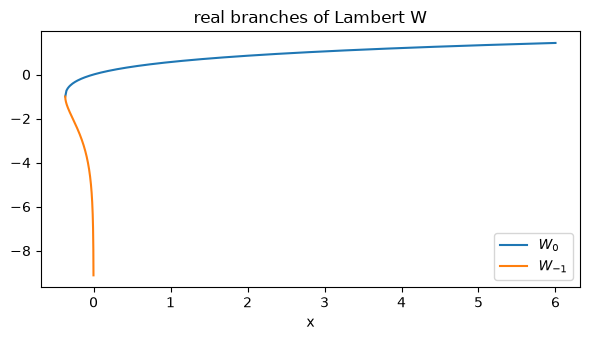

In [4]:
xg = np.linspace(-1 / np.e + 1e-9, 6.0, 400)
xg_neg = np.linspace(-1 / np.e + 1e-9, -1e-3, 400)
plt.figure(figsize=(6, 3.5))
plt.plot(xg, chebax.lambertw(xg), label="$W_0$")
plt.plot(xg_neg, chebax.lambertw(xg_neg, k=-1), label="$W_{-1}$")
plt.xlabel("x")
plt.legend()
plt.title("real branches of Lambert W")
plt.tight_layout()

S = 0.3
G_low = -chebax.lambertw(-S)
G_high = -chebax.lambertw(-S, k=-1)
print(f"throughput S = {S}: load G = {float(G_low):.6f} (low) "
      f"or {float(G_high):.6f} (congested)")
print("check S = G e^-G:", float(G_low * jnp.exp(-G_low)),
      float(G_high * jnp.exp(-G_high)))
dG = jax.grad(lambda s: -chebax.lambertw(-s))(S)
print(f"sensitivity dG/dS on the low branch: {float(dG):.6f}")

## betainc with gradients in the shape parameters (jax#38610)

`betainc_fn(a, b, x)` is differentiable in all three arguments. One
thing that unlocks: the binomial tail P(X >= k | n, p) = I_p(k, n-k+1)
becomes a smooth function of p, so reliability targets can be solved or
optimized with plain Newton on jax gradients.

per-trial success needed for 95% reliability: p = 0.877149


check: P(X >= 9) = 0.950000, scipy: 0.950000


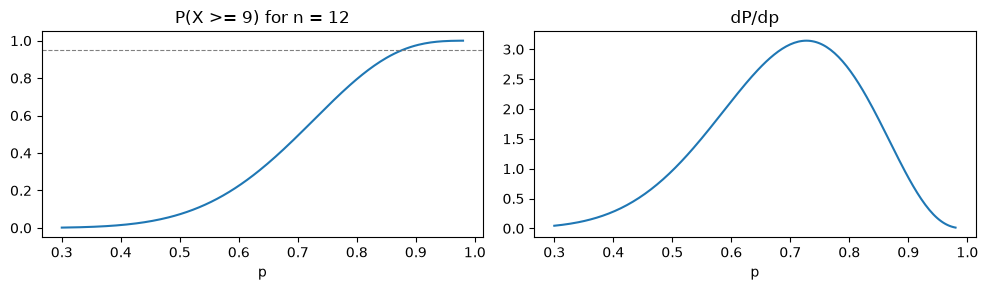

In [5]:
n, k = 12, 9  # need at least 9 successes out of 12

def reliability(p):
    return chebax.betainc_fn(float(k), float(n - k + 1), p)

pg = jnp.linspace(0.3, 0.98, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(pg, jax.vmap(reliability)(pg))
ax1.axhline(0.95, color="gray", lw=0.8, ls="--")
ax1.set_xlabel("p")
ax1.set_title(f"P(X >= {k}) for n = {n}")
ax2.plot(pg, jax.vmap(jax.grad(reliability))(pg))
ax2.set_xlabel("p")
ax2.set_title("dP/dp")
plt.tight_layout()

# Newton for the p that achieves 95% reliability
p = jnp.asarray(0.8)
for _ in range(6):
    p = p - (reliability(p) - 0.95) / jax.grad(reliability)(p)
print(f"per-trial success needed for 95% reliability: p = {float(p):.6f}")
print(f"check: P(X >= {k}) = {float(reliability(p)):.6f}, "
      f"scipy: {float(sps.betainc(k, n - k + 1, float(p))):.6f}")

The shape-parameter gradients themselves, against central differences:

In [6]:
a0, b0, x0 = 2.0, 3.0, 0.4
ga = jax.grad(chebax.betainc_fn, argnums=0)(a0, b0, x0)
gb = jax.grad(chebax.betainc_fn, argnums=1)(a0, b0, x0)
h = 1e-6
fa = (sps.betainc(a0 + h, b0, x0) - sps.betainc(a0 - h, b0, x0)) / (2 * h)
fb = (sps.betainc(a0, b0 + h, x0) - sps.betainc(a0, b0 - h, x0)) / (2 * h)
print(f"dI/da: grad {float(ga):+.10f}, central diff {fa:+.10f}")
print(f"dI/db: grad {float(gb):+.10f}, central diff {fb:+.10f}")

dI/da: grad -0.2408693761, central diff -0.2408693762
dI/db: grad +0.1563443364, central diff +0.1563443364
